# Evaluación y selección de modelo: `implementation_success`

- **Desbalance leve** (45 % éxito / 55 % fracaso) → conviene validación estratificada, no hace falta remuestreo.
- **Señal real:** `feasibility_score`, `automation_potential`, `data_availability` y `process_complexity`. `monthly_volume` y `avg_minutes` no se relacionan con el éxito.
- **Pocos datos (160 filas)** → priorizar modelos simples y vigilar el sobreajuste.
- **Siguiente paso definido en el EDA:** comparar una regresión logística base contra un Random Forest con más variables, midiendo F1 y ROC-AUC.

Este notebook sigue ese plan y termina exportando el modelo elegido, listo para que prediga sobre procesos nuevos.

**Flujo**
1. Carga de datos y transformación logarítmica
2. Preparación de variables y separación train/test
3. Comparación de modelos por validación cruzada
4. Evaluación final en el conjunto de prueba
5. Selección, reentrenamiento y exportación del modelo

## 1. Carga de datos y transformación logarítmica

In [3]:
# Importación de librerías y configuración inicial
import json
import platform
import warnings
from pathlib import Path

import joblib
import numpy as np
import pandas as pd
import sklearn
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.compose import ColumnTransformer
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
import sklearn.metrics as metrics
from sklearn.model_selection import (GridSearchCV, StratifiedKFold,
                                      cross_validate, train_test_split)
from sklearn.preprocessing import StandardScaler, OrdinalEncoder


#! Configuración de opciones
warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams["figure.dpi"] = 100
pd.set_option("display.max_columns", 30)

#! Configuración de constantes
RANDOM_STATE = 12345
TARGET = "implementation_success"
IDS = "project_id"
PATH_HIST = "../data/outputs/1A_historical_ai_projects.csv"   # Datos para construir los modelos

CARPETA_SALIDA = Path("../models")
CARPETA_SALIDA.mkdir(exist_ok=True)

In [4]:
# Carga y transformación logarítmica de la variable annual_hours
historical = pd.read_csv(PATH_HIST)
historical["log_annual_hours"] = np.log1p(historical["annual_hours"])

print(f"historical: {historical.shape[0]} filas x {historical.shape[1]} columnas")
historical.head()

historical: 160 filas x 15 columnas


,project_id,department,process_name,monthly_volume,avg_minutes,manual_share,data_availability,process_complexity,implementation_success,annual_hours,automation_potential,recoverable_hours,estimated_annual_benefit,feasibility_score,log_annual_hours
0,H0001,Operations,Customer onboarding,315,28.5,0.683,1,4,0,1795.50,0.4415,792.71,23781398.0,0.20,7.493596
1,H0002,Procurement,Data consolidation,184,9.8,0.886,1,5,0,360.64,0.5030,181.40,5442058.0,0.12,5.890649
2,H0003,Procurement,Monthly reporting,224,18.9,0.809,4,1,1,846.72,0.8045,681.19,20435587.0,0.80,6.742550
3,H0004,Operations,Data consolidation,328,13.0,0.879,5,1,1,852.80,0.8995,767.09,23012808.0,0.92,6.749697
4,H0005,IT,Customer data entry,164,8.5,0.709,5,1,1,278.80,0.8145,227.08,6812478.0,0.92,5.634075


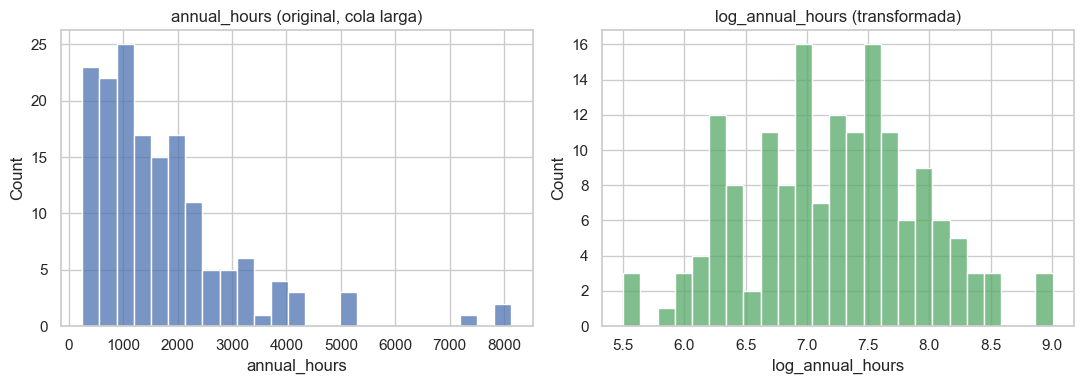

In [5]:
# Visualización de la distribución de la variable annual_hours y su transformación logarítmica
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
sns.histplot(historical["annual_hours"], bins=25, ax=axes[0], color="#4C72B0")
axes[0].set_title("annual_hours (original, cola larga)")
sns.histplot(historical["log_annual_hours"], bins=25, ax=axes[1], color="#55A868")
axes[1].set_title("log_annual_hours (transformada)")
plt.tight_layout()
plt.show()

## 2. Preparación de variables y separación train/test

Dos conjuntos de variables:

- **`FEATURES_BASE`** (regresión logística): `department`, `data_availability`, `process_complexity`, `manual_share`, `log_annual_hours`. Pocas variables, poco redundantes entre sí, fáciles de explicar. Los departamentos seran codificados con OHE.
- **`FEATURES_FULL`** (Random Forest): todas las variables numéricas originales y derivadas — salvo `estimated_annual_benefit`, que es `recoverable_hours` multiplicada por una constante y no aporta información nueva, `department` y `process_name`**, codificadas con Ordinal Encoding.

### 2.1 Preparación de datos para el modelo de regresión logística

In [6]:
# Aplicación de OHE en departamentos
logistic_set = pd.get_dummies(historical, columns=["department"], drop_first=True)
bool_cols = logistic_set.select_dtypes('bool').columns
logistic_set[bool_cols] = logistic_set[bool_cols].astype(int)

# Estandarización de features numéricas
num_cols = ["manual_share", "data_availability", "process_complexity",
            "log_annual_hours"]
scaler = StandardScaler()
logistic_set[num_cols] = scaler.fit_transform(logistic_set[num_cols])

# Separacion de columnas identificadoras, features y target
logistic_features = [*num_cols, *bool_cols]

df_identifiers = logistic_set[IDS]
df_target = logistic_set[TARGET]
logistic_df_features = logistic_set[logistic_features]

# Visualización de las primeras filas del conjunto de features y target
print("Primeras filas del conjunto de features:")
display(logistic_df_features.head())

Primeras filas del conjunto de features:


,manual_share,data_availability,process_complexity,log_annual_hours,department_Finance,department_Human Resources,department_IT,department_Logistics,department_Operations,department_Procurement,department_Sales
0,-0.114032,-1.600642,0.587388,0.404983,0,0,0,0,1,0,0
1,1.177380,-1.600642,1.268418,-1.855477,0,0,0,0,0,1,0
2,0.687534,0.515909,-1.455701,-0.654134,0,0,0,0,0,1,0
3,1.132849,1.221426,-1.455701,-0.644056,0,0,0,0,1,0,0
4,0.051370,1.221426,-1.455701,-2.217295,0,0,1,0,0,0,0


### 2.2 Preparación de datos para el modelo de bosque aleatorio

In [7]:
# Aplicación de codificación de etiquetas (Ordinal Encoding)
forest_set = historical.copy()

encoder = OrdinalEncoder()
forest_set[["department", "process_name"]] = encoder.fit_transform(forest_set[["department", "process_name"]])


# Separacion de columnas identificadoras, features y target
forest_features = forest_set.drop(columns=[IDS, TARGET]).columns

forest_df_target = forest_set[TARGET]
forest_df_features = forest_set[forest_features]

# Visualización de las primeras filas del conjunto de features y target
print("Primeras filas del conjunto de features:")
display(forest_df_features.head())

Primeras filas del conjunto de features:


,department,process_name,monthly_volume,avg_minutes,manual_share,data_availability,process_complexity,annual_hours,automation_potential,recoverable_hours,estimated_annual_benefit,feasibility_score,log_annual_hours
0,5.0,5.0,315,28.5,0.683,1,4,1795.50,0.4415,792.71,23781398.0,0.20,7.493596
1,6.0,6.0,184,9.8,0.886,1,5,360.64,0.5030,181.40,5442058.0,0.12,5.890649
2,6.0,11.0,224,18.9,0.809,4,1,846.72,0.8045,681.19,20435587.0,0.80,6.742550
3,5.0,6.0,328,13.0,0.879,5,1,852.80,0.8995,767.09,23012808.0,0.92,6.749697
4,3.0,4.0,164,8.5,0.709,5,1,278.80,0.8145,227.08,6812478.0,0.92,5.634075


### 2.3 Selección de conjunto de entrenamiento (80%) y pruebas (20%)

In [8]:
# División del conjunto de datos en entrenamiento y prueba
id_train, id_test, y_train, y_test = train_test_split(
    df_identifiers, df_target, test_size=0.2, stratify=df_target, random_state=RANDOM_STATE
)
print(f"train: {len(id_train)} filas ({y_train.mean():.0%} éxito) | "
      f"test: {len(id_test)} filas ({y_test.mean():.0%} éxito)")

display(id_train.head())
display(y_train.head())

train: 128 filas (45% éxito) | test: 32 filas (44% éxito)


35    H0036
86    H0087
81    H0082
44    H0045
83    H0084
Name: project_id, dtype: object

35    0
86    1
81    0
44    1
83    1
Name: implementation_success, dtype: int64

## 3. Comparación de modelos por validación cruzada

Con solo 128 filas de entrenamiento, un único reparto train/test tiene mucha varianza. Se usa `StratifiedKFold` (5 particiones, conservando la proporción de clases) sobre el conjunto de entrenamiento, y se deja el conjunto de prueba intacto para la evaluación final del modelo ganador.

Métricas: **F1** (balance entre precisión y recall) y **ROC-AUC** (qué tan bien separa el modelo las dos clases, independiente del umbral).

### 3.1 Modelo de Regresión Logistica

In [ ]:
# Definición de modelo de regresión logística
modelo_lr = LogisticRegression(class_weight="balanced", random_state=RANDOM_STATE)

### 3.2 Modelo de Bosque Aleatorio

In [ ]:
# Variables de resultados de exactitud.
best_score = 0
best_n_estimators = 0
best_depth = 0

# Evaluación de profundidad.
for depth in range(1, 7):
    for estimators in range(10, 51, 10):
        modelo_rf = RandomForestClassifier(class_weight="balanced", random_state=RANDOM_STATE, max_depth = depth, n_estimators=estimators)
        modelo_rf.fit(forest_df_features.loc[id_train.index], y_train)
        score = modelo_rf.score(forest_df_features.loc[id_test.index], y_test)
        if score > best_score:
            best_score = score
            best_depth = depth
            best_n_estimators = estimators
        
# Imprimir el resultado
print("La exactitud del mejor modelo en el conjunto de validación (profundidad = {}, n_estimators = {}): {}".format(best_depth, best_n_estimators, best_score))

# Selección del mejor modelo con los hiperparámetros óptimos.
modelo_rf = RandomForestClassifier(n_estimators=best_n_estimators, max_depth=best_depth, class_weight="balanced", random_state=RANDOM_STATE)

La exactitud del mejor modelo en el conjunto de validación (profundidad = 1, n_estimators = 10): 0.6875


### 3.3 Comparación con validación cruzada

,F1 (media),F1 (± sd),ROC-AUC (media),ROC-AUC (± sd)
modelo,,,,
Regresión logística,0.590,0.090,0.693,0.095
Random Forest,0.666,0.131,0.750,0.117


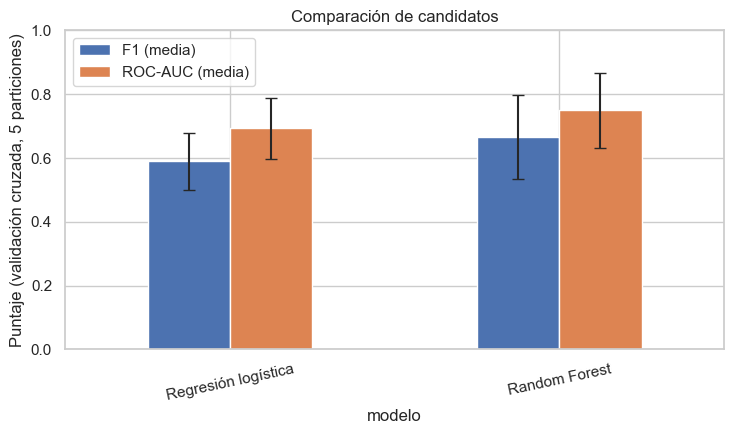

In [19]:
# Evaluación de modelos candidatos mediante validación cruzada.
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
scoring = {"f1": "f1", "roc_auc": "roc_auc"}

candidatos = {
    "Regresión logística": (modelo_lr, logistic_features),
    "Random Forest": (modelo_rf, forest_features),
}

filas = []
for nombre, (model, cols) in candidatos.items():
    res = cross_validate(model, logistic_df_features.loc[id_train.index] if nombre == "Regresión logística" else forest_df_features.loc[id_train.index], y_train, cv=cv, scoring=scoring)
    filas.append({
        "modelo": nombre,
        "F1 (media)": res["test_f1"].mean(), "F1 (± sd)": res["test_f1"].std(),
        "ROC-AUC (media)": res["test_roc_auc"].mean(), "ROC-AUC (± sd)": res["test_roc_auc"].std(),
    })

comparacion = pd.DataFrame(filas).set_index("modelo").round(3)
display(comparacion)

fig, ax = plt.subplots(figsize=(7.5, 4.5))
comparacion[["F1 (media)", "ROC-AUC (media)"]].plot.bar(ax=ax, rot=12,
    yerr=comparacion[["F1 (± sd)", "ROC-AUC (± sd)"]].values.T, capsize=4)
ax.set_ylim(0, 1)
ax.set_ylabel("Puntaje (validación cruzada, 5 particiones)")
ax.set_title("Comparación de candidatos")
plt.tight_layout()
plt.show()

## 4. Evaluación final en el conjunto de prueba

El 20 % de prueba que no participó en la validación cruzada, para tener una estimación honesta de qué tan bien generaliza cada modelo.

In [14]:
def evaluate_model(model, train_features, train_target, test_features, test_target):

    eval_stats = {}

    fig, axs = plt.subplots(1, 3, figsize=(20, 6))

    for type, features, target in (('train', train_features, train_target), ('test', test_features, test_target)):

        eval_stats[type] = {}

        pred_target = model.predict(features)
        pred_proba = model.predict_proba(features)[:, 1]

        # F1
        f1_thresholds = np.arange(0, 1.01, 0.05)
        f1_scores = [metrics.f1_score(target, pred_proba>=threshold) for threshold in f1_thresholds]

        # ROC
        fpr, tpr, roc_thresholds = metrics.roc_curve(target, pred_proba)
        roc_auc = metrics.roc_auc_score(target, pred_proba)
        eval_stats[type]['ROC AUC'] = roc_auc

        # PRC
        precision, recall, pr_thresholds = metrics.precision_recall_curve(target, pred_proba)
        aps = metrics.average_precision_score(target, pred_proba)
        eval_stats[type]['APS'] = aps

        if type == 'train':
            color = 'blue'
        else:
            color = 'green'

        # Valor F1
        ax = axs[0]
        max_f1_score_idx = np.argmax(f1_scores)
        ax.plot(f1_thresholds, f1_scores, color=color, label=f'{type}, max={f1_scores[max_f1_score_idx]:.2f} @ {f1_thresholds[max_f1_score_idx]:.2f}')
        # establecer cruces para algunos umbrales
        for threshold in (0.2, 0.4, 0.5, 0.6, 0.8):
            closest_value_idx = np.argmin(np.abs(f1_thresholds-threshold))
            marker_color = 'orange' if threshold != 0.5 else 'red'
            ax.plot(f1_thresholds[closest_value_idx], f1_scores[closest_value_idx], color=marker_color, marker='X', markersize=7)
        ax.set_xlim([-0.02, 1.02])
        ax.set_ylim([-0.02, 1.02])
        ax.set_xlabel('threshold')
        ax.set_ylabel('F1')
        ax.legend(loc='lower center')
        ax.set_title(f'Valor F1')

        # ROC
        ax = axs[1]
        ax.plot(fpr, tpr, color=color, label=f'{type}, ROC AUC={roc_auc:.2f}')
        # establecer cruces para algunos umbrales
        for threshold in (0.2, 0.4, 0.5, 0.6, 0.8):
            closest_value_idx = np.argmin(np.abs(roc_thresholds-threshold))
            marker_color = 'orange' if threshold != 0.5 else 'red'
            ax.plot(fpr[closest_value_idx], tpr[closest_value_idx], color=marker_color, marker='X', markersize=7)
        ax.plot([0, 1], [0, 1], color='grey', linestyle='--')
        ax.set_xlim([-0.02, 1.02])
        ax.set_ylim([-0.02, 1.02])
        ax.set_xlabel('FPR')
        ax.set_ylabel('TPR')
        ax.legend(loc='lower center')
        ax.set_title(f'Curva ROC')

        # PRC
        ax = axs[2]
        ax.plot(recall, precision, color=color, label=f'{type}, AP={aps:.2f}')
        # establecer cruces para algunos umbrales
        for threshold in (0.2, 0.4, 0.5, 0.6, 0.8):
            closest_value_idx = np.argmin(np.abs(pr_thresholds-threshold))
            marker_color = 'orange' if threshold != 0.5 else 'red'
            ax.plot(recall[closest_value_idx], precision[closest_value_idx], color=marker_color, marker='X', markersize=7)
        ax.set_xlim([-0.02, 1.02])
        ax.set_ylim([-0.02, 1.02])
        ax.set_xlabel('recall')
        ax.set_ylabel('precision')
        ax.legend(loc='lower center')
        ax.set_title(f'PRC')

        eval_stats[type]['Accuracy'] = metrics.accuracy_score(target, pred_target)
        eval_stats[type]['F1'] = metrics.f1_score(target, pred_target)

    df_eval_stats = pd.DataFrame(eval_stats)
    df_eval_stats = df_eval_stats.round(2)
    df_eval_stats = df_eval_stats.reindex(index=('Accuracy', 'F1', 'APS', 'ROC AUC'))

    print(df_eval_stats)
    
    return df_eval_stats

          train  test
Accuracy   0.72  0.59
F1         0.70  0.52
APS        0.78  0.69
ROC AUC    0.79  0.61


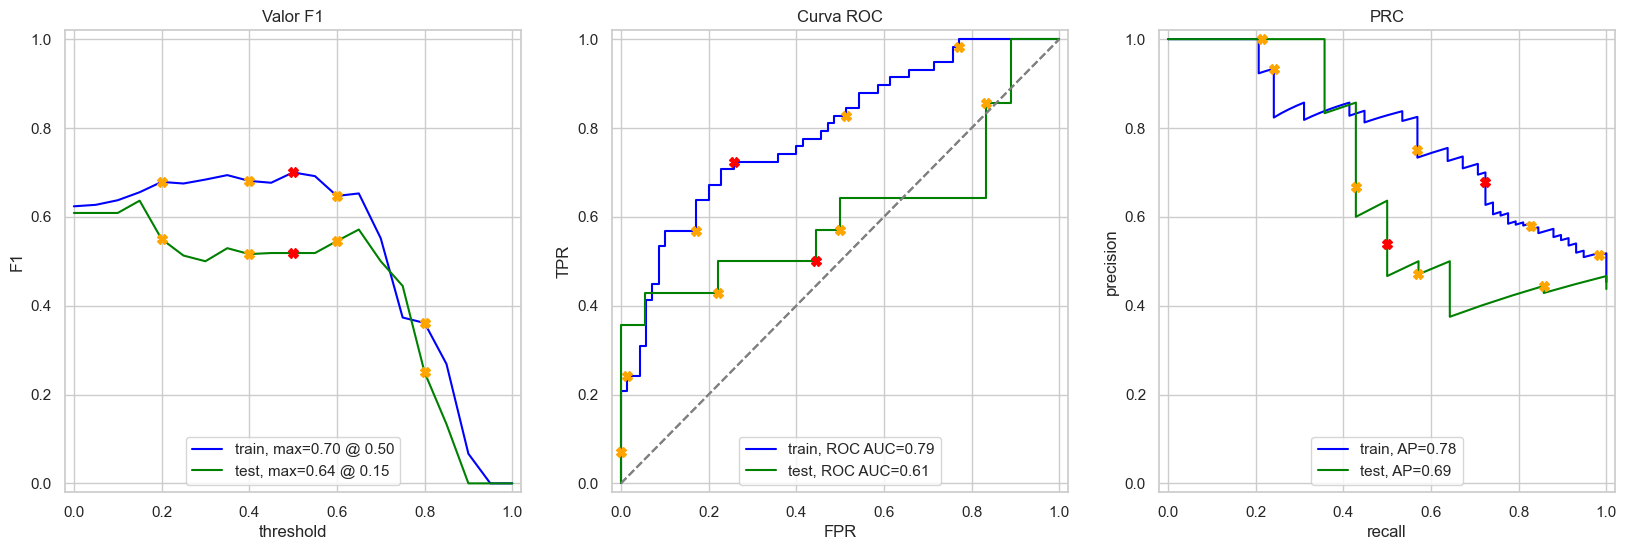

In [16]:
# Evaluación de desempeño del modelo de regresión logística
modelo_lr.fit(logistic_df_features.loc[id_train.index], y_train)
model_lr_results = evaluate_model(modelo_lr, logistic_df_features.loc[id_train.index], y_train, logistic_df_features.loc[id_test.index], y_test)

          train  test
Accuracy   0.74  0.69
F1         0.71  0.62
APS        0.77  0.63
ROC AUC    0.79  0.69


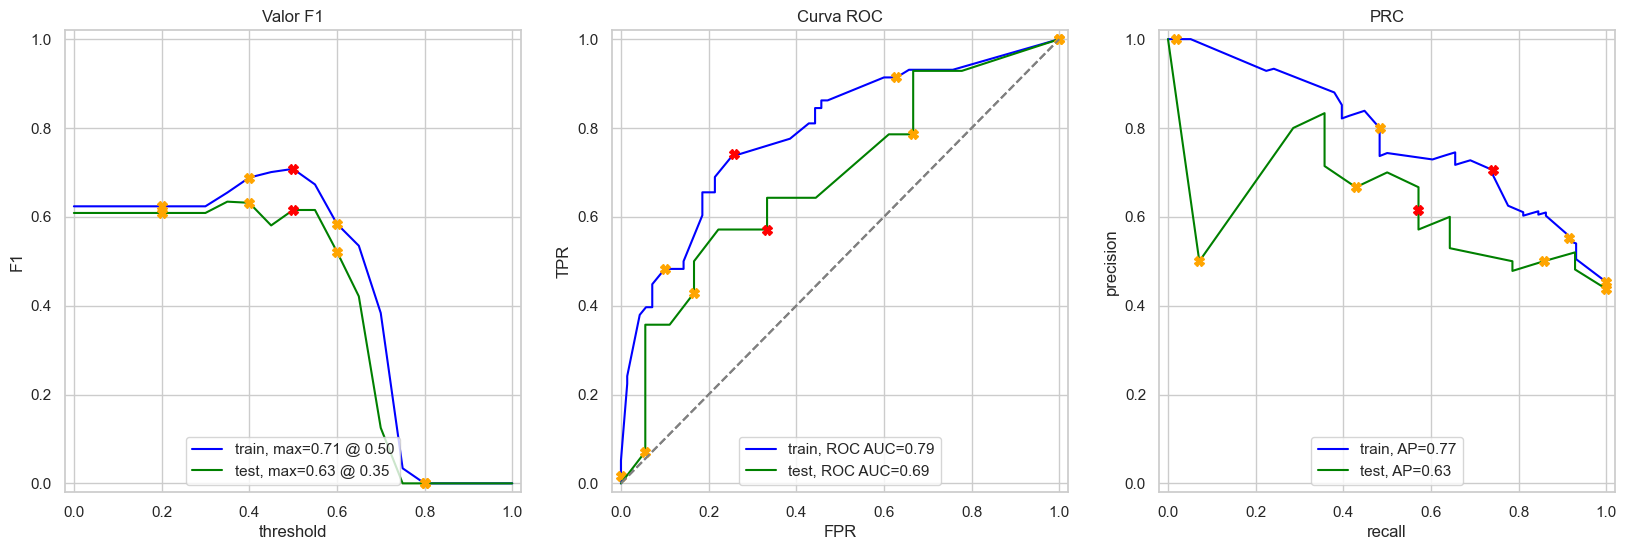

In [17]:
# Evaluación de desempeño del modelo de bosque aleatorio
modelo_rf.fit(forest_df_features.loc[id_train.index], y_train)
model_rf_results = evaluate_model(modelo_rf, forest_df_features.loc[id_train.index], y_train, forest_df_features.loc[id_test.index], y_test)

### Elección del modelo

En validación cruzada el Random Forest queda ligeramente por delante (F1 = 0,66 frente a 0,59 de la logística) y, sobre todo, con menos variación entre particiones (± 0,09 frente a ± 0,131): eso importa porque un modelo más estable es menos sensible a qué filas cayeron en cada partición.

En el conjunto de prueba el Random Forest gana en las dos métricas: F1 = 0,62 frente a 0,52, y ROC-AUC = 0,69 frente a 0,61.

Se elige el **Random Forest** (con `department` y `process_name`) como modelo del proyecto:
- Mejor F1 y más estable en validación cruzada, y mejor F1 en la prueba final.
- La importancia de variables confirma que `automation_potential` y `feasibility_score` son las que más pesan, seguidas de `manual_share` y `recoverable_hours` — coherente con lo que ya mostraba el EDA. `department` y `process_name` sí aportan algo (la categoría de Recursos Humanos es la más relevante de las dos), pero mucho menos que las variables numéricas; el modelo no depende de ellas para funcionar.
- Se mantiene un threshold de 0.5 para la clasificación ya que mantiene el mayor balance en las metricas conjuntas.


## 5. Selección, reentrenamiento y exportación

Con el modelo ya elegido, se reentrena sobre **todos** los datos históricos (train + test) para aprovechar al máximo la información disponible antes de exportarlo — el conjunto de prueba ya cumplió su función de evaluación honesta en el paso anterior.

In [40]:
# Entrenamiento y guardado del modelo final Random Forest con umbral 0.5
MODELO_FINAL_NOMBRE = "Random Forest Classificator (Threshold 0.5)"

modelo_final = modelo_rf
modelo_final.fit(forest_df_features, df_target)

ruta_modelo = f"{CARPETA_SALIDA}/modelo_implementation_success.joblib"
joblib.dump(modelo_final, ruta_modelo)
print(f"Modelo guardado en: {ruta_modelo}")

Modelo guardado en: ..\models/modelo_implementation_success.joblib


In [ ]:
# Guardado de la metadata del modelo final
metadata = {
    "modelo": MODELO_FINAL_NOMBRE,
    "target": TARGET,
    "columnas_entrada": forest_df_features.columns.tolist(),
    "n_entrenamiento": int(len(historical)),
    "metricas_test": {
        "f1": round(model_rf_results["test"]["F1"], 3),
        "roc_auc": round(model_rf_results["test"]["ROC AUC"], 3),
    },
    "hiperparametros": {"n_estimators": best_n_estimators, "max_depth": best_depth},
    "sklearn_version": sklearn.__version__,
    "python_version": platform.python_version(),
}
with open(f"{CARPETA_SALIDA}/metadata_modelo.json", "w", encoding="utf-8") as f:
    json.dump(metadata, f, ensure_ascii=False, indent=2)

print(json.dumps(metadata, ensure_ascii=False, indent=2))

{
  "modelo": "Random Forest Classificator (Threshold 0.5)",
  "target": "implementation_success",
  "columnas_entrada": [
    "department",
    "process_name",
    "monthly_volume",
    "avg_minutes",
    "manual_share",
    "data_availability",
    "process_complexity",
    "annual_hours",
    "automation_potential",
    "recoverable_hours",
    "estimated_annual_benefit",
    "feasibility_score",
    "log_annual_hours"
  ],
  "n_entrenamiento": 160,
  "metricas_test": {
    "f1": 0.62,
    "roc_auc": 0.69
  },
  "hiperparametros": {
    "n_estimators": 10,
    "max_depth": 1
  },
  "sklearn_version": "1.6.1",
  "python_version": "3.12.8"
}


`modelo_implementation_success.joblib` espera un DataFrame con exactamente las columnas listadas en `columnas_entrada`. `metadata_modelo.json` documenta esas columnas, las métricas de prueba y los hiperparámetros, para no tener que abrir el notebook cada vez que alguien necesite esa información.

## 6. Prueba de carga del modelo exportado

Se carga el `.joblib` desde cero, igual que lo haría cualquier script o notebook que lo use más adelante, y se predice sobre una fila nueva.

In [42]:
modelo_cargado = joblib.load(ruta_modelo)

ejemplo = forest_df_features[forest_features].iloc[[0]]
probabilidad = modelo_cargado.predict_proba(ejemplo)[:, 1][0]
prediccion = modelo_cargado.predict(ejemplo)[0]
print(f"Probabilidad de éxito: {probabilidad:.1%} | Predicción: {'Éxito' if prediccion else 'Fracaso'}")

Probabilidad de éxito: 39.3% | Predicción: Fracaso
